# Reference Card Extraction

This notebook now explores the reusable extraction code in `src/uno_vision/data/reference_cards.py`.
The heavy lifting lives in the package; the cells here focus on picking inputs, running the extractor, and visualizing the generated assets.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from uno_vision.data.reference_cards import (
    _mask_pipeline_steps,
    extract_reference_card_assets,
    load_reference_image,
    plot_crop_preview,
    plot_pipeline_steps,
)
from uno_vision.paths import REFERENCE_CARDS_DIR, REFERENCE_IMAGES_DIR

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference images: {REFERENCE_IMAGES_DIR}")
print(f"Processed outputs: {REFERENCE_CARDS_DIR}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo
Reference images: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\raw\reference_images
Processed outputs: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\reference_cards


In [ ]:
# ── Image selection ──────────────────────────────────────────────────────────
# Map each reference image to its expected card count.
image_components = {
    "L1000765": 12,
    "L1000766": 12,
    "L1000767": 14,
    "L1000768": 16,
}

# None → process every entry above; or restrict to a subset, e.g. ["L1000768"]
images_to_process = None

# Which image to use for the single-image preview cells (mask viz + crop grid).
preview_image_name = "L1000765"

# ── Hyperparameters (in order of application) ────────────────────────────────

# ── Phase 1 · Adaptive threshold + skeletonize ───────────────────────────────

# [Step 1] Adaptive threshold — binarize using local Gaussian neighborhood
adaptive_block_size = 11   # block size (must be odd, >= 3)
adaptive_c = 4             # constant subtracted from weighted mean

# [Step 2] Median blur — denoise the thresholded image
pre_blur_size = 3          # kernel size (must be odd)

# [Step 3] Morphological DILATE — expand foreground before skeletonize
dilate_size_1 = 9         # kernel size in pixels

# [Step 4] Skeletonize — reduce blobs to single-pixel-wide skeletons (no parameter)

# [Step 5] Morphological DILATE — thicken skeleton for contour detection
dilate_size_2 = 16         # kernel size in pixels

# [Step 6] Median blur — smooth the dilated skeleton
post_blur_size = 9         # kernel size (must be odd)

# ── Phase 2 · Component filtering ────────────────────────────────────────────

# [Step 7] Small-contour removal — erase regions below area threshold
min_area_abs = 12000      # minimum component area in pixels

# [Step 8] Aspect-ratio filter — keep only card-shaped connected components
min_ar = 0.3               # minimum bounding-box aspect ratio w/h
max_ar = 2.0               # maximum bounding-box aspect ratio w/h

pipeline_kwargs = dict(
    adaptive_block_size=adaptive_block_size, adaptive_c=adaptive_c,
    pre_blur_size=pre_blur_size,
    dilate_size_1=dilate_size_1, dilate_size_2=dilate_size_2,
    post_blur_size=post_blur_size,
    min_area_abs=min_area_abs,
    min_ar=min_ar, max_ar=max_ar,
)

In [ ]:
gray, color_rgb = load_reference_image(preview_image_name)
pipeline_steps = _mask_pipeline_steps(gray, **pipeline_kwargs)
print(f"Image shape: {gray.shape}")

Image shape: (2662, 4000)


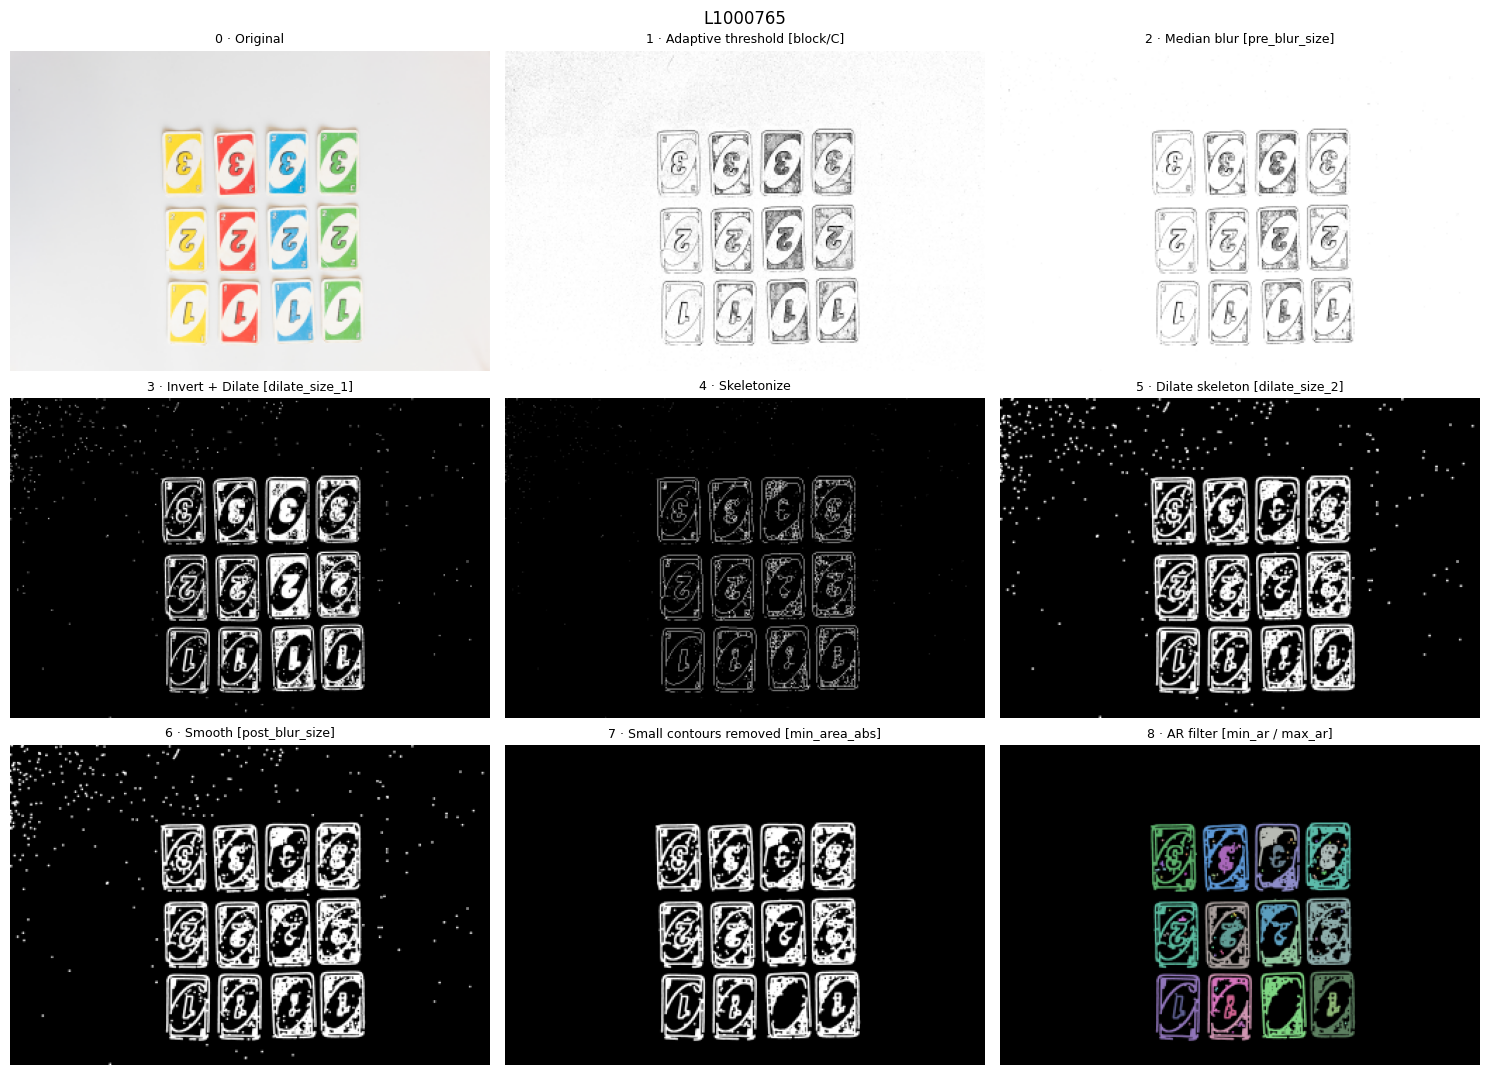

In [ ]:
plot_pipeline_steps(color_rgb, pipeline_steps, preview_image_name)

In [ ]:
selected = list(image_components.keys()) if images_to_process is None else images_to_process

results: dict[str, object] = {}
for name in selected:
    r = extract_reference_card_assets(
        image_name=name, num_components=image_components[name], **pipeline_kwargs
    )
    results[name] = r
    print(f"{name}: {len(r.components)} components, {len(r.masks)} masks, {len(r.crops)} crops")

L1000765: 12 components, 12 masks, 12 crops
L1000766: 12 components, 12 masks, 12 crops
L1000767: 14 components, 14 masks, 14 crops
L1000768: 16 components, 16 masks, 16 crops


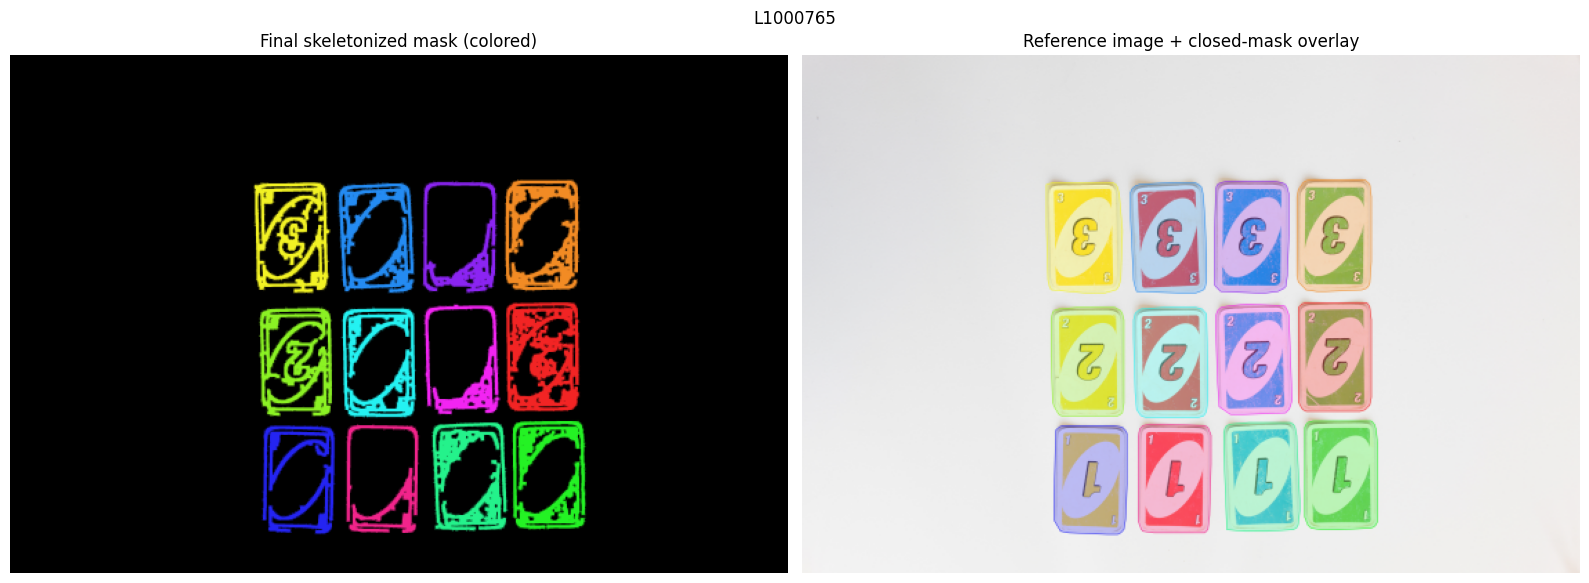

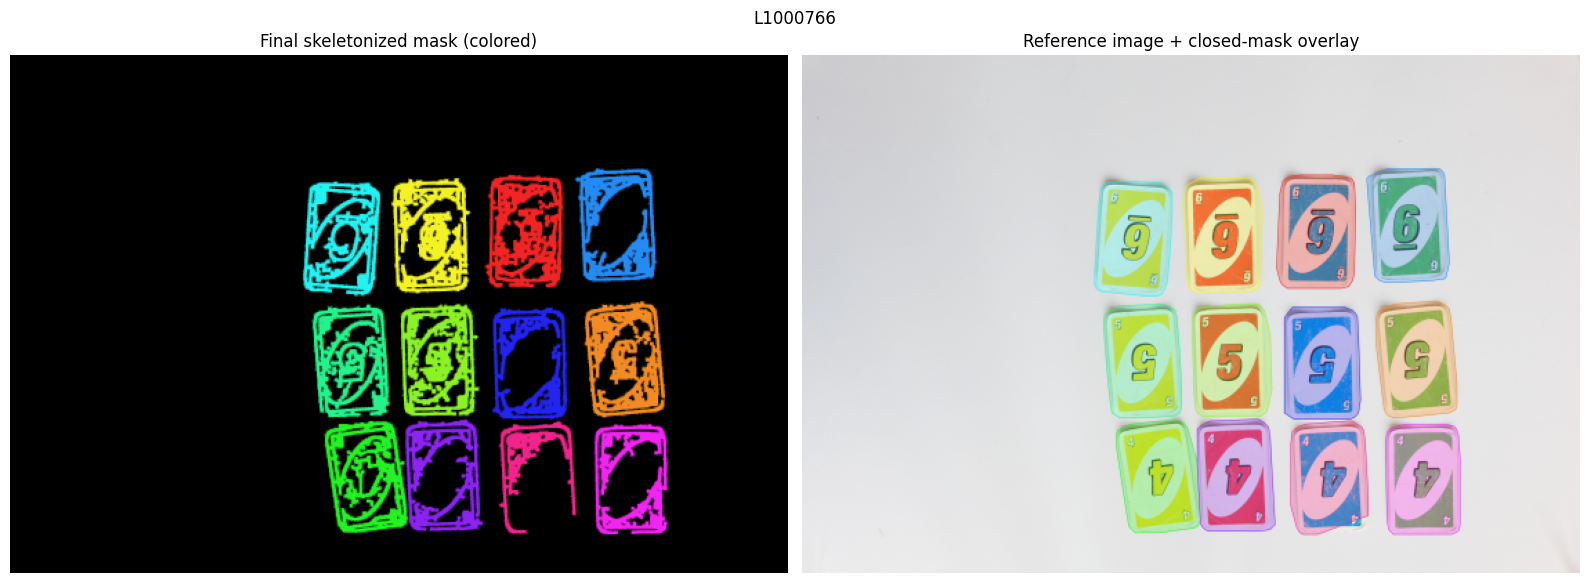

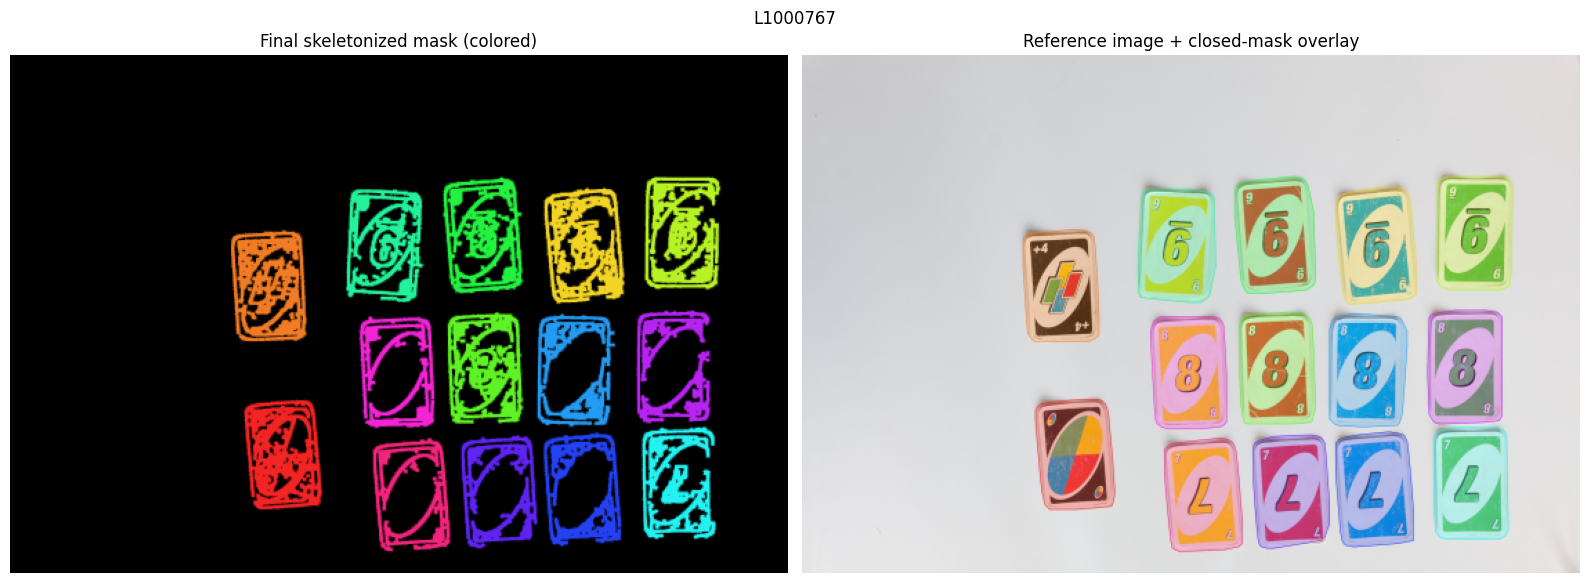

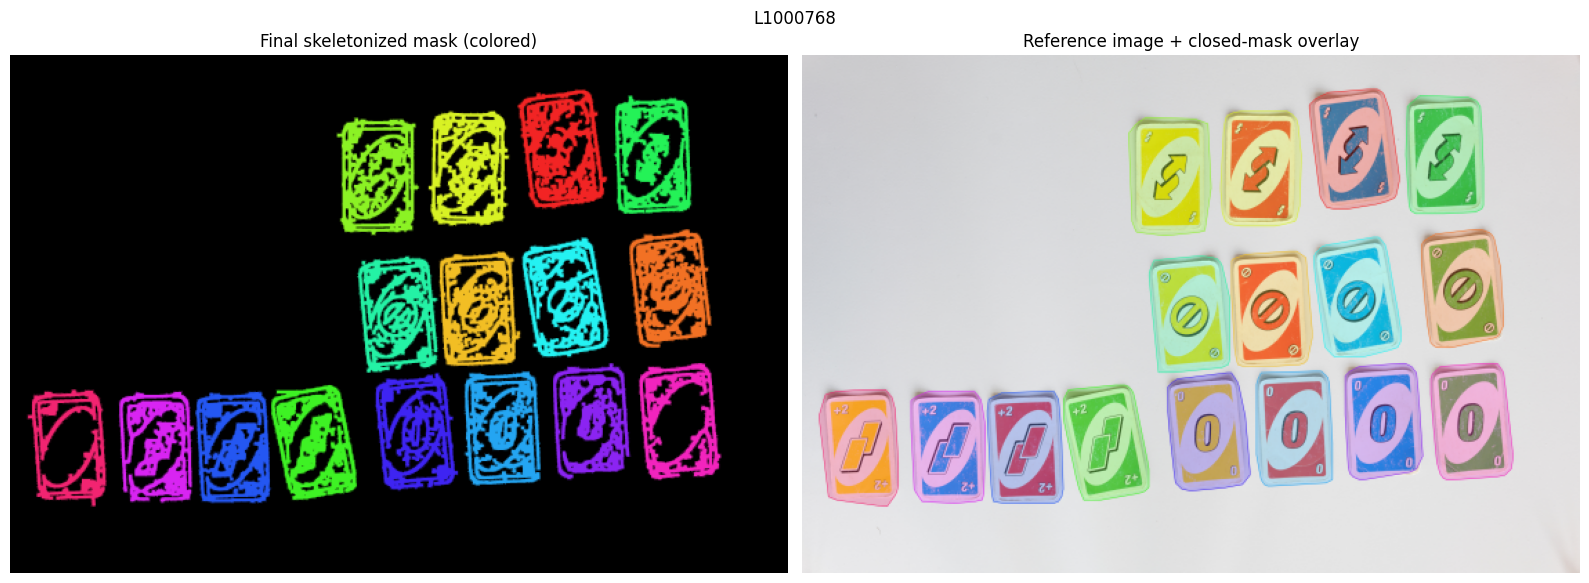

In [ ]:
for name, result in results.items():
    plot_crop_preview(result, title=name)